In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping



print('Setup is ready!')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date

Setup is ready!


In [3]:
df = pd.read_csv('/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/training_data_fixed.csv')
df.head()


,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [4]:
print('Shape:', df.shape)
print('Kolommen:', df.columns.tolist())
print('Datatypes:')
print(df.dtypes)
print('Lege waarden:')
print(df.isnull().sum())


Shape: (34152, 2)
Kolommen: ['label', 'text']
Datatypes:
label    int64
text       str
dtype: object
Lege waarden:
label    0
text     0
dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)


Train: (27321,)
Test:  (6831,)


In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()

def preprocess(text):
    # 1. HTML cleaning - uitgecommentarieerd: data bevat geen HTML
    # text = re.sub(r"<(script|style).*?>.*?</\1>", "", text, flags=re.DOTALL)
    # text = re.sub(r"<!--.*?-->", "", text, flags=re.DOTALL)
    # text = re.sub(r"<.*?>", "", text)

    # 2. Prefixed b - uitgecommentarieerd: data bevat geen bytes strings
    # text = re.sub(r"^b\s+", "", text)

    # 3. Lowercase - uitgecommentarieerd: data is al lowercase
    # text = text.lower()

    # 4. Special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 5. Numbers
    text = re.sub(r"\d+", " ", text)

    # 6. Losse letters
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    text = re.sub(r"^\s*[a-zA-Z]\s+", " ", text)

    # 7. Dubbele spaties
    text = re.sub(r"\s+", " ", text).strip()

    # 8. Tokenization - MOET voor stopwords en lemmatization!
    tokens = word_tokenize(text)

    # 9. Punctuation removal
    tokens = [w for w in tokens if w not in string.punctuation]

    # 10. Stopwords - MOET na lowercase EN na tokenization!
    tokens = [w for w in tokens if w not in stop_words]

    # 11. Lemmatization - werkt op individuele tokens!
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # 12. Terug samenvoegen naar string
    return " ".join(tokens)

# Toepassen - apart op train en test
X_train = X_train.apply(preprocess)
X_test  = X_test.apply(preprocess)

print("Na preprocessing:")
print(X_train.iloc[0])


Na preprocessing:



In [7]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)


TF-IDF shape: (27321, 20000)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [9]:
# Train accuracy Logistic Regression with lemmatization and TF-IDF
y_train_pred = model.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, y_train_pred)

# Test accuracy
y_test_pred = model.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)


Train accuracy: 0.9601039493429963
Test accuracy: 0.9330991070121505


In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)



In [11]:
y_train_pred_nb = nb_model.predict(X_train_tfidf)
train_acc_nb = accuracy_score(y_train, y_train_pred_nb)

# Test accuracy
y_test_pred_nb = nb_model.predict(X_test_tfidf)
test_acc_nb = accuracy_score(y_test, y_test_pred_nb)

print("Train accuracy:", train_acc_nb)
print("Test accuracy:", test_acc_nb)



Train accuracy: 0.9538084257530837
Test accuracy: 0.930171277997365


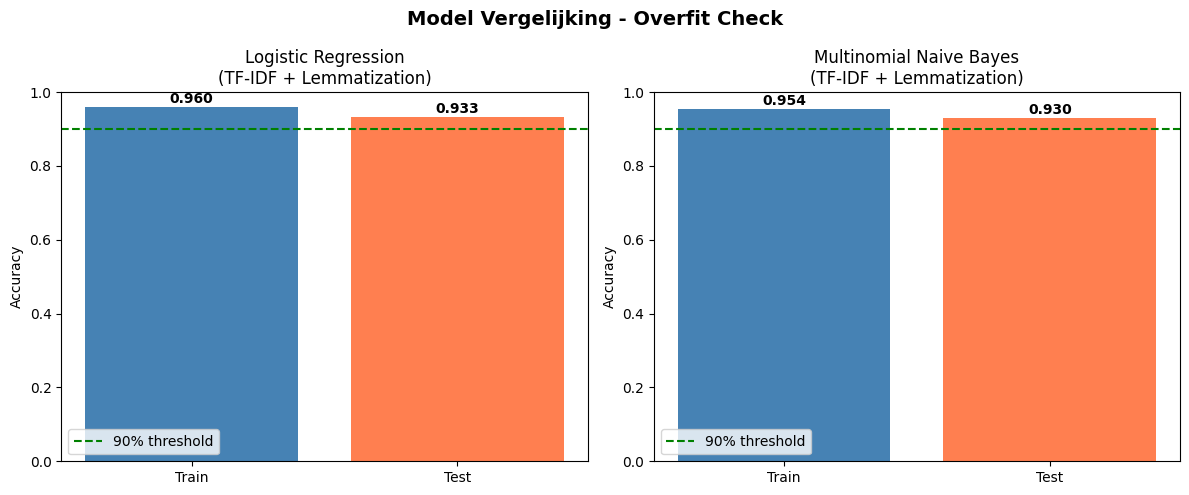

Logistic Regression → Train: 0.960 | Test: 0.933 | Verschil: 0.027
Naive Bayes         → Train: 0.954 | Test: 0.930 | Verschil: 0.024


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
axes[0].bar(['Train', 'Test'], [train_acc, test_acc], color=['steelblue', 'coral'])
axes[0].set_title('Logistic Regression\n(TF-IDF + Lemmatization)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
for i, v in enumerate([train_acc, test_acc]):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].legend()

# Naive Bayes
axes[1].bar(['Train', 'Test'], [train_acc_nb, test_acc_nb], color=['steelblue', 'coral'])
axes[1].set_title('Multinomial Naive Bayes\n(TF-IDF + Lemmatization)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
for i, v in enumerate([train_acc_nb, test_acc_nb]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Vergelijking - Overfit Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Samenvatting
print(f'Logistic Regression → Train: {train_acc:.3f} | Test: {test_acc:.3f} | Verschil: {abs(train_acc-test_acc):.3f}')
print(f'Naive Bayes         → Train: {train_acc_nb:.3f} | Test: {test_acc_nb:.3f} | Verschil: {abs(train_acc_nb-test_acc_nb):.3f}')

In [14]:
# Laad testdata
df_test = pd.read_csv("/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/testing_data_lowercase_nolabels.csv", 
                       header=None, sep="\t", names=["id", "text"])

# Preprocess
df_test["text"] = df_test["text"].apply(preprocess)

# Transformeer
X_test_new = tfidf.transform(df_test["text"])

# Voorspel
df_test["label"] = model.predict(X_test_new)

# Bekijk
print(df_test.head(10))
print("\nVerdeling:", df_test["label"].value_counts())

  id                                               text  label
0  2   copycat muslim terrorist arrested assault weapon      0
1  2  wow chicago protester caught camera admits vio...      0
2  2           germany fdp look fill schaeuble big shoe      1
3  2  mi school sends welcome back packet warning ki...      0
4  2  seek massive aid boost amid rohingya emergency...      1
5  2   oprah leave nasty hillary wishing endorsed video      0
6  2  france macron say job cool cite talk turkey er...      1
7  2  flashback chilling minute interview george sor...      0
8  2  spanish foreign ministry say expel north korea...      1
9  2            trump say cuba bad thing aimed diplomat      1

Verdeling: label
1    5241
0    4743
Name: count, dtype: int64


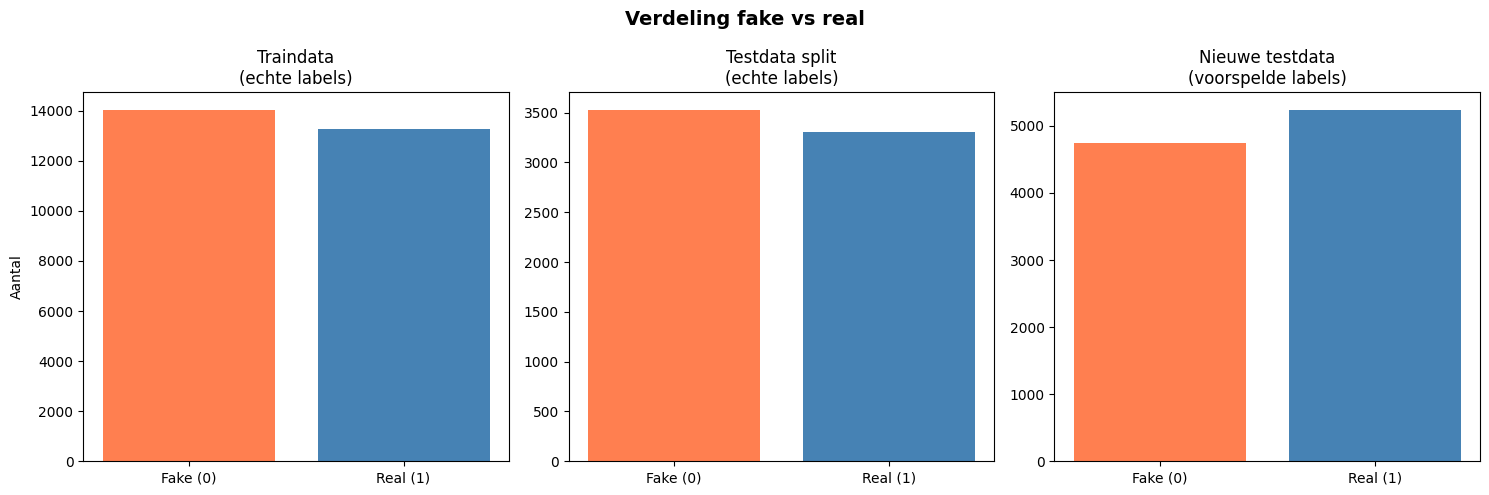

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Train verdeling (echte labels)
axes[0].bar(['Fake (0)', 'Real (1)'], 
            [y_train.value_counts()[0], y_train.value_counts()[1]], 
            color=['coral', 'steelblue'])
axes[0].set_title('Traindata\n(echte labels)')
axes[0].set_ylabel('Aantal')

# Test verdeling (echte labels)
axes[1].bar(['Fake (0)', 'Real (1)'], 
            [y_test.value_counts()[0], y_test.value_counts()[1]], 
            color=['coral', 'steelblue'])
axes[1].set_title('Testdata split\n(echte labels)')

# Nieuwe testdata verdeling (voorspelde labels)
axes[2].bar(['Fake (0)', 'Real (1)'], 
            [df_test['label'].value_counts()[0], df_test['label'].value_counts()[1]], 
            color=['coral', 'steelblue'])
axes[2].set_title('Nieuwe testdata\n(voorspelde labels)')

plt.suptitle('Verdeling fake vs real', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

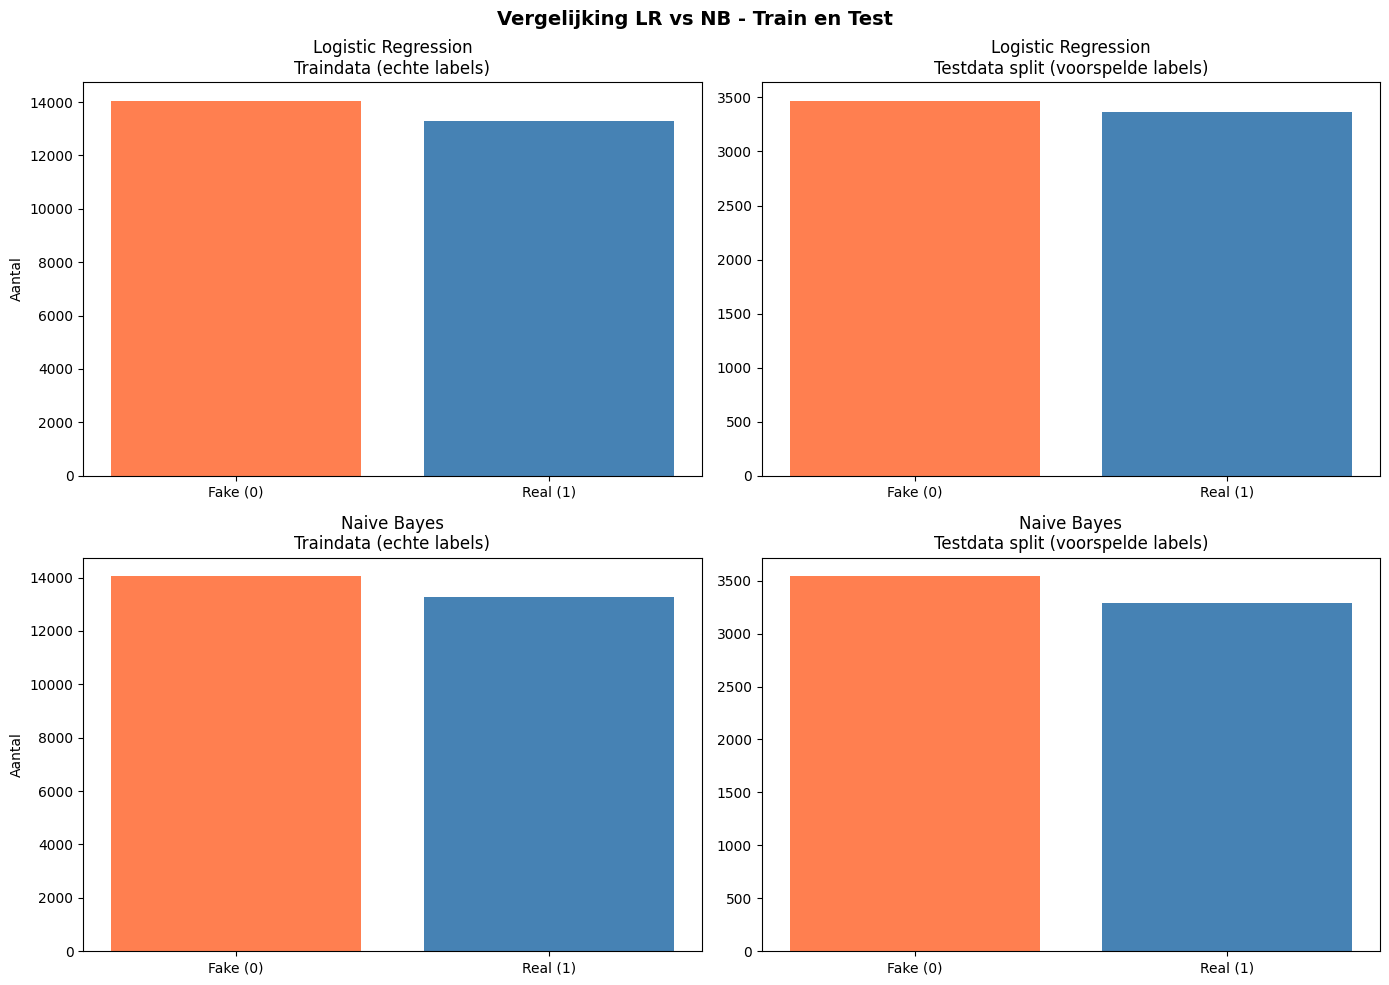

Logistic Regression → Train: 0.960 | Test: 0.933
Naive Bayes         → Train: 0.954 | Test: 0.930


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LR op traindata
axes[0][0].bar(['Fake (0)', 'Real (1)'],
               [y_train.value_counts()[0], y_train.value_counts()[1]],
               color=['coral', 'steelblue'])
axes[0][0].set_title('Logistic Regression\nTraindata (echte labels)')
axes[0][0].set_ylabel('Aantal')

# LR op testdata split
axes[0][1].bar(['Fake (0)', 'Real (1)'],
               [(y_test_pred == 0).sum(), (y_test_pred == 1).sum()],
               color=['coral', 'steelblue'])
axes[0][1].set_title('Logistic Regression\nTestdata split (voorspelde labels)')

# NB op traindata
axes[1][0].bar(['Fake (0)', 'Real (1)'],
               [y_train.value_counts()[0], y_train.value_counts()[1]],
               color=['coral', 'steelblue'])
axes[1][0].set_title('Naive Bayes\nTraindata (echte labels)')
axes[1][0].set_ylabel('Aantal')

# NB op testdata split
axes[1][1].bar(['Fake (0)', 'Real (1)'],
               [(y_test_pred_nb == 0).sum(), (y_test_pred_nb == 1).sum()],
               color=['coral', 'steelblue'])
axes[1][1].set_title('Naive Bayes\nTestdata split (voorspelde labels)')

plt.suptitle('Vergelijking LR vs NB - Train en Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Accuracies
print(f'Logistic Regression → Train: {train_acc:.3f} | Test: {test_acc:.3f}')
print(f'Naive Bayes         → Train: {train_acc_nb:.3f} | Test: {test_acc_nb:.3f}')

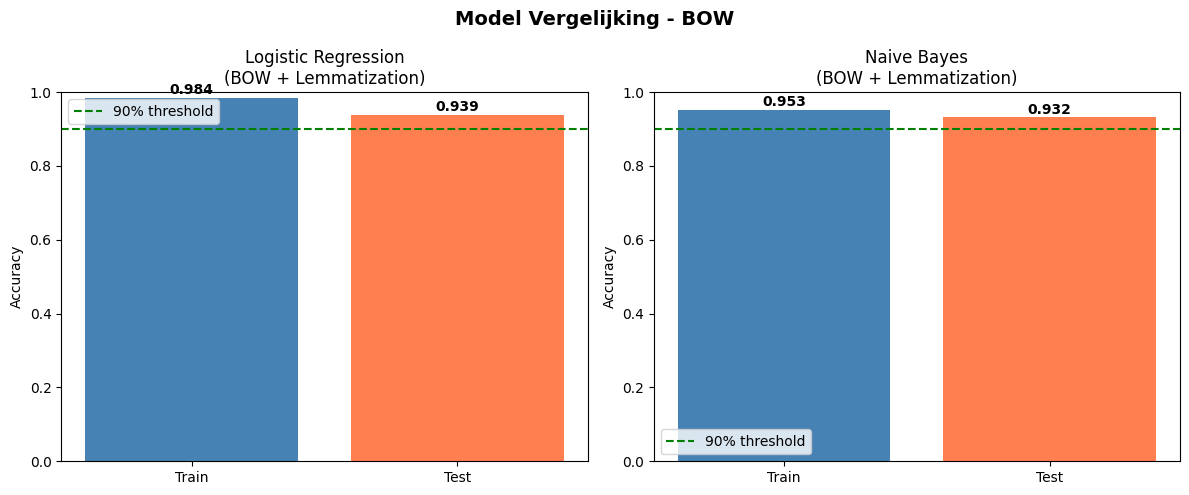

BOW + LR → Train: 0.984 | Test: 0.939 | Verschil: 0.045
BOW + NB → Train: 0.953 | Test: 0.932 | Verschil: 0.021


In [22]:
# BOW vectorizer
cv = CountVectorizer(max_features=20000, ngram_range=(1,2))
X_train_bow = cv.fit_transform(X_train)
X_test_bow  = cv.transform(X_test)

# LR met BOW
model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, y_train)
train_acc_bow    = accuracy_score(y_train, model_bow.predict(X_train_bow))
test_acc_bow     = accuracy_score(y_test,  model_bow.predict(X_test_bow))

# NB met BOW
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
train_acc_nb_bow = accuracy_score(y_train, nb_bow.predict(X_train_bow))
test_acc_nb_bow  = accuracy_score(y_test,  nb_bow.predict(X_test_bow))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR BOW
axes[0].bar(['Train', 'Test'], [train_acc_bow, test_acc_bow], color=['steelblue', 'coral'])
axes[0].set_title('Logistic Regression\n(BOW + Lemmatization)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
for i, v in enumerate([train_acc_bow, test_acc_bow]):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].legend()

# NB BOW
axes[1].bar(['Train', 'Test'], [train_acc_nb_bow, test_acc_nb_bow], color=['steelblue', 'coral'])
axes[1].set_title('Naive Bayes\n(BOW + Lemmatization)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
for i, v in enumerate([train_acc_nb_bow, test_acc_nb_bow]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Vergelijking - BOW', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'BOW + LR → Train: {train_acc_bow:.3f} | Test: {test_acc_bow:.3f} | Verschil: {abs(train_acc_bow-test_acc_bow):.3f}')
print(f'BOW + NB → Train: {train_acc_nb_bow:.3f} | Test: {test_acc_nb_bow:.3f} | Verschil: {abs(train_acc_nb_bow-test_acc_nb_bow):.3f}')

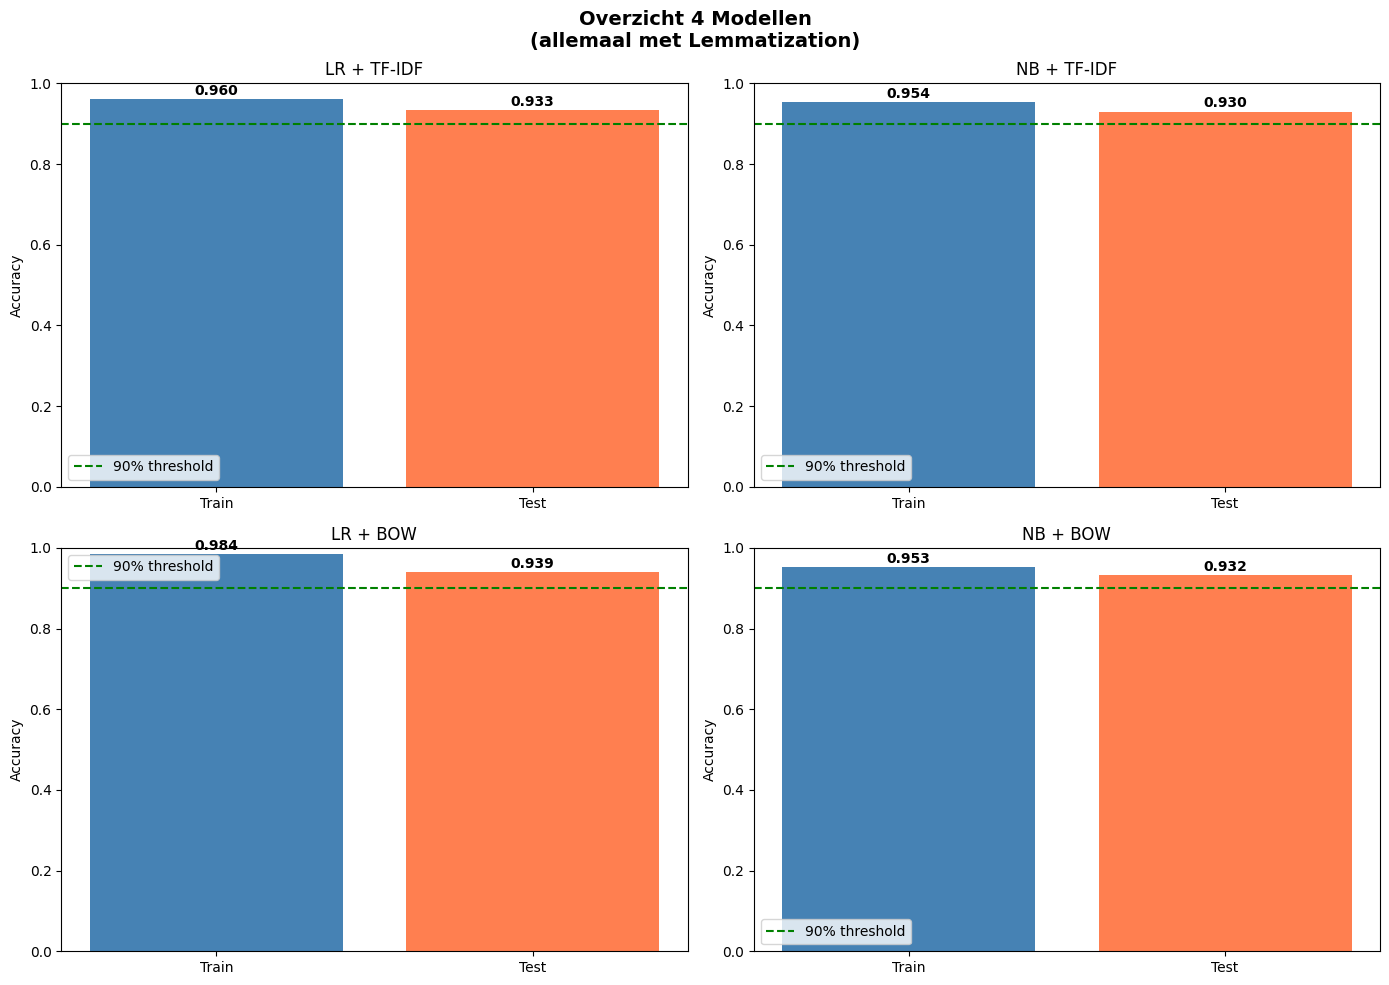

LR  + TF-IDF → Train: 0.960        | Test: 0.933        | Verschil: 0.027
NB  + TF-IDF → Train: 0.954     | Test: 0.930     | Verschil: 0.024
LR  + BOW    → Train: 0.984    | Test: 0.939    | Verschil: 0.045
NB  + BOW    → Train: 0.953 | Test: 0.932 | Verschil: 0.021


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

modellen = [
    (axes[0][0], 'LR + TF-IDF',  train_acc,        test_acc),
    (axes[0][1], 'NB + TF-IDF',  train_acc_nb,     test_acc_nb),
    (axes[1][0], 'LR + BOW',     train_acc_bow,    test_acc_bow),
    (axes[1][1], 'NB + BOW',     train_acc_nb_bow, test_acc_nb_bow),
]

for ax, titel, train, test in modellen:
    ax.bar(['Train', 'Test'], [train, test], color=['steelblue', 'coral'])
    ax.set_title(titel)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
    for i, v in enumerate([train, test]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
    ax.legend()

plt.suptitle('Overzicht 4 Modellen\n(allemaal met Lemmatization)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'LR  + TF-IDF → Train: {train_acc:.3f}        | Test: {test_acc:.3f}        | Verschil: {abs(train_acc-test_acc):.3f}')
print(f'NB  + TF-IDF → Train: {train_acc_nb:.3f}     | Test: {test_acc_nb:.3f}     | Verschil: {abs(train_acc_nb-test_acc_nb):.3f}')
print(f'LR  + BOW    → Train: {train_acc_bow:.3f}    | Test: {test_acc_bow:.3f}    | Verschil: {abs(train_acc_bow-test_acc_bow):.3f}')
print(f'NB  + BOW    → Train: {train_acc_nb_bow:.3f} | Test: {test_acc_nb_bow:.3f} | Verschil: {abs(train_acc_nb_bow-test_acc_nb_bow):.3f}')